# Does and how does Income Inequality Influence Violent Crime Rates in Baltimore from 2012 to 2017 in a significant way?

###### words: 4477 without reference

## 1. Project 1

### 1.1 Introduction

With violent crime being a growing concern in modern society, understating the correlation between income levels and the frequency of violent crime in economic conditions is significant for policymaking (Fajnzylber et al., 2002). This study examined whether and how income inequality significantly impacted the violent crime rates in Baltimore from 2012 to 2017. Previous research has explored the relationship between economic inequality and crime, highlighting the effect of unemployment, education and income disparities (Sampson et al., 1997). Unlike previous research that has established a general link between economic factors and crime at the national or transnational levels (Yildiz et al., 2013), this study focuses on community-level crime patterns to provide a perspective on a specific city. 

The economic theory of crime indicates that individuals weigh the potential benefits of criminal activity against the risk of punishment (Becker, 1968)  is the basic method to predict the probability of crime for the individual. Low-income areas tend to have higher unemployment and limited education opportunities, making crime a rational choice for economic survival (Grogger, 1998). Previous research also shows juvenile crime rate is very sensitive to wage fluctuations, reinforcing the relationship between economic hardship and violent crime (Gillani, Rehman, & Gill, 2009). However, economics alone cannot fully explain criminal patterns. Research showed that social structures such as neighbourhood stability and policing forces also impact crime rates (Chalfin & McCrary, 2017).

All the datasets used in this research come from the OpenBaltimore website, which involves economic indicators such as household income, unemployment rate, dropout rate, mortgage foreclosure rates, juvenile arrest rate, liquor outlet density, CitiWatch cameras and neighbourhood classification. Income level is the main predictor, as economic hardship is often considered a primary driving factor of criminal activity (Raphael & Winter-Ebmer, 2001). this study introduced the mental health service data from the 988 Suicide and Crisis Lifeline to recognize the complex social background. These data provide a deeper insight into inequality in access and the availability of social infrastructure services. This study also applies machine learning to reveal non-linear relationships and hidden interaction effects in predicting violent crime.

Serval hypotheses emerge from this framework. Firstly, low-income neighbourhoods are expected to experience higher rates of violent crime due to economic regression, unemployment and educational challenges. Secondly, if economic conditions improve over time, violent crime rates may decline, and persistent economic disparities may sustain high crime rates (Ehrlich, 1973). Thirdly, structural factors such as foreclosure rates and liquor export density may simulate crime rates by promoting social disorder (Levitt, 1996). By focusing only on violent crime, this study aims to contribute a more nuanced understanding of crime patterns by identifying the most related economic and social factors, avoiding a general and predictable conclusion.   

### 1.2 Data Cleaning/Loading

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import numpy as np
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from linearmodels.iv import IV2SLS

from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

from sklearn import (
    linear_model, metrics, pipeline, model_selection, tree
)

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.edge.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

import time

### 1.2.1 Data Selection
The dependent variable Y is the violent crime rate, as the study was designed to explore its relationship to economic factors. Independent X variables include income level, unemployment rate, high school dropout rate, total population, mortgage foreclosure rates, juvenile arrest rate, liquor outlet density, and CitiWatch camera locations. Income level is the main predictor, as economic differences affect crime patterns. Unemployment and high school dropout rates were included to assess whether a lack of economic and educational opportunities may lead to higher crime rates, while the total population controlled for differences in community size. Mortgage foreclosure rates indicate the effect of economic instability on damage to community structure, which leads to crime. Juvenile arrest rate and liquor outlet density can be used to predict social environment risks, while CitiWatch's camera location helps analyze the role of surveillance in crime prevention. Moreover, neighbourhoods and years are considered predictors for interpreting local patterns and crime dynamics, which differ based on time and region.

### 1.2.2 Data Cleaning
Datasets are cleaned to ensure accuracy and consistency. Community Statistical Area (CSA) classifications, which are a dictionary, are incorporated into CrimeBal to align all the datasets based on neighbourhoods. The datasets are broken down by year to analyze trends over time. Income quartiles (low, lower middle, upper middle, high) are created, and categorical variables (neighbourhood) are standardized. Finally, all datasets are merged into CrimeBal, ensuring each observation retains current information for a more accurate examination.

In [38]:
# Load datasets
CrimeBal = pd.read_csv('CleanedCrimeBal.csv')
camera_data = pd.read_csv("WatchCamera.csv")
juvenile_arrestR = pd.read_csv('JuvenileArrestRate.csv')
mental_health = pd.read_csv("MentalHealthServices.csv")

In [39]:
juvenile_arrestR = juvenile_arrestR.rename(columns={'Community Statistical Area (CSA)': 'CSA2020', '2015': 'JuvenileArrestRate'})
CrimeBal = CrimeBal.merge(juvenile_arrestR[['CSA2020', 'JuvenileArrestRate']], on='CSA2020', how='left')

### 1.3 Summary Statistics Tables

In [35]:
# Summary statistics for key variables
summary_stats = CrimeBal[['Income', 'Dropout', 'ViolentCrime', 'Unemployment', 'TotalPopulation']].describe().T
print(summary_stats)

                    count          mean           std           min  \
Income           231767.0  41392.066250  19657.173146  13478.164520   
Dropout          231767.0      3.242091      1.894919      0.000000   
ViolentCrime     231767.0     20.453253     13.935884      0.537057   
Unemployment     231767.0     14.468123      6.477974      1.989013   
TotalPopulation  231767.0  12263.450168   4411.836773   4101.000000   

                          25%           50%           75%            max  
Income           29975.856480  37160.584750  44186.154470  113496.137900  
Dropout              2.010050      3.094778      4.347826      10.344828  
ViolentCrime        12.344970     17.539898     24.711363      97.579895  
Unemployment         9.569509     14.841200     18.694885      29.913793  
TotalPopulation   9039.000000  11816.000000  15020.000000   23557.000000  


### 1.3.1 Summary Statistics Table for Key Variables 
This table summarizes the five key variables: income level, dropout rate, violent rate, unemployment rate and total population. The mean household income is \$41394, ranging from \$13478 to \$113496, indicating a wide disparity. The mean dropout rate is 3.24 percent, and 10.34 percent is the maximum, suggesting that education is challenged in some areas. The mean violent crime rate per 1000 residents is 20.45 incidents and peaked at 97.57, indicating a high concentration of crime. There was a similar trend in the unemployment rate, with a mean value of 20.45 percent, which mentions a possible link between unemployment and the violent crime rate. This table shows that the economic situation of different neighbourhoods has widely varied. This wide variation in crime rate demonstrates that economic factors may play a significant role in crime patterns.

In [40]:
# Creating income quartiles
CrimeBal['IncomeGroup'] = pd.qcut(CrimeBal['Income'], q=4, labels=['Low', 'Lower-Middle', 'Upper-Middle', 'High'])

# Aggregated statistics based on income groups
income_group_summary = CrimeBal.groupby('IncomeGroup', observed=True)[['ViolentCrime', 'Unemployment', 'Dropout']].mean()
print(income_group_summary)

              ViolentCrime  Unemployment   Dropout
IncomeGroup                                       
Low              24.894435     20.602350  4.100278
Lower-Middle     18.237773     16.283645  3.346424
Upper-Middle     19.434858     13.202089  2.508691
High             19.200231      7.746949  3.007618


### 1.3.2 Summary Table with Sub-Groups
This table divides communities into four groups: Low, Lower-Middle, Upper-Middle, and High-Middle. Low-income areas have the highest violent crime rate and the highest unemployment rate. Interestingly, while the violent crime rate decreased in middle-income areas, it remained stable in Upper-middle and high-income regions, indicating a threshold effect where crime reduction is less significant beyond a certain income level. Grouping the income data helps visualize the impact of economic inequality on crime.

### 1.4 Plots, Histograms, Figures 

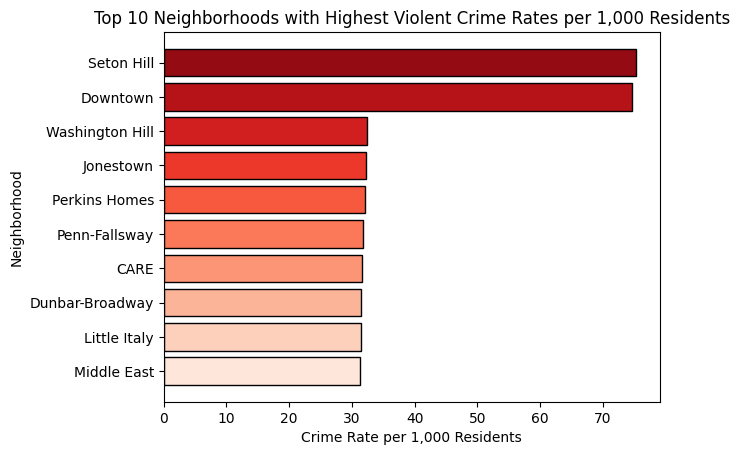

In [ ]:
## 1. Bar Chart: Crime rate per 1,000 residents by neighborhood
top_neigh = CrimeBal.groupby("Neighborhood")["ViolentCrime"].mean().nlargest(10).sort_values()

colors = sns.color_palette("Reds", len(top_neigh))  
bars = plt.barh(top_neigh.index, top_neigh.values, color=colors, edgecolor="black")

plt.xlabel("Crime Rate per 1,000 Residents")
plt.ylabel("Neighborhood")
plt.title("Top 10 Neighborhoods with Highest Violent Crime Rates per 1,000 Residents")
plt.grid(axis='x', linestyle='', alpha=0.7)

ax = plt.gca()
plt.show()

This bar chart shows the first ten neighbourhoods with the highest violent crime rate per 1000 residents using a colour gradient to distinguish crime intensity. Seton Hill (75.3) and Downtown (74.6) have the highest rates, compared to other areas at 32.5 and below. This highlights the concentration of crime in specific neighbourhoods, representing external factors, such as income level, unemployment, or education gap, that may contribute to the crime disparities across Baltimore.

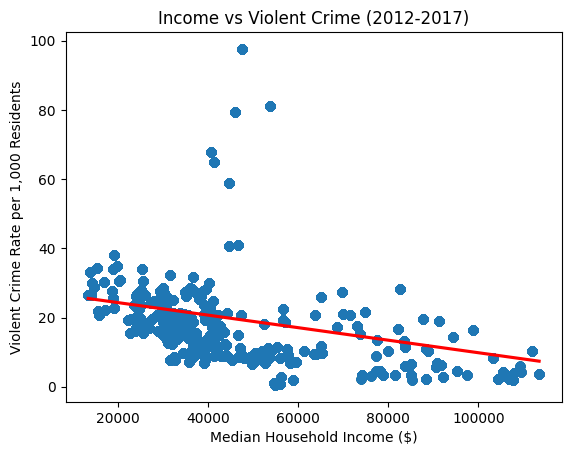

In [ ]:
## 2. Scatterplot: Violent crimes vs income (2012-2017)
sns.regplot(
    x=CrimeBal['Income'], 
    y=CrimeBal['ViolentCrime'], 
    scatter=True, 
    fit_reg=True,  
    scatter_kws={'alpha': 0.5}, 
    line_kws={"color": "red"},  
)

plt.xlabel("Median Household Income ($)")
plt.ylabel("Violent Crime Rate per 1,000 Residents")
plt.title("Income vs Violent Crime (2012-2017)")
plt.grid(axis='y', linestyle='', alpha=0.7)

plt.show()

The scatter plot examines the relationship between household income levels and violent crime rates from 2012-2017. A clear negative correlation indicated that low-income neighbourhoods tend to have higher violent crime rates. Neighbours with income below $40000 have an average violent crime rate of 20-40 incidents per 1000 residents, while high-income areas with more than 80000 residents seldom have more than 20. The presence of outliers suggests that high crime rates are not only caused by low income, highlighting the necessity of exploring other confounder variables.

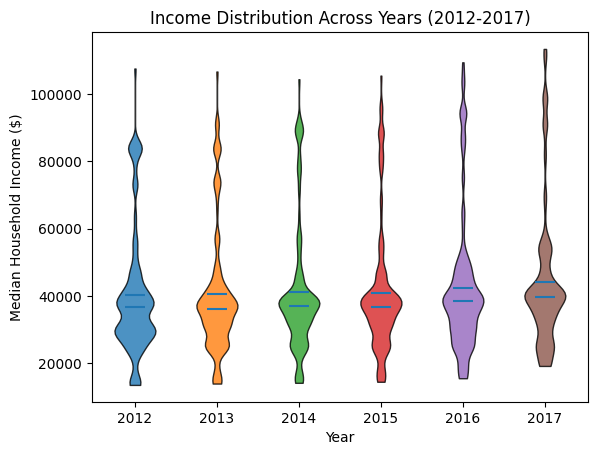

In [ ]:
## 3. Violin plot: Income Distribution across the year
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
years = list(range(2012, 2018))

# Prepare the data
CrimeBal = CrimeBal.copy() 
CrimeBal.loc[:, "Income"] = pd.to_numeric(CrimeBal["Income"], errors="coerce")
CrimeBal = CrimeBal.dropna(subset=["Income"])
if CrimeBal["Income"].dropna().empty:
    raise ValueError("No valid income data available after cleaning.")

# Group income data by year
data_by_year = []
for year in years:
    yearly_data = CrimeBal[CrimeBal["CrimeYear"] == year]["Income"].dropna()
    data_by_year.append(yearly_data.values)

# Create the violin plot
fig, ax = plt.subplots()
parts = ax.violinplot(data_by_year, showmeans=True, showmedians=True, showextrema=False)

# Set individual colors for each violin
for i, violin in enumerate(parts['bodies']):
    violin.set_facecolor(colors[i])
    violin.set_edgecolor("black")
    violin.set_alpha(0.8)

# Set x-axis ticks and labels
ax.set_xticks(np.arange(1, len(years)+1))
ax.set_xticklabels(years)
ax.set_xlabel("Year")
ax.set_ylabel("Median Household Income ($)")
ax.set_title("Income Distribution Across Years (2012-2017)")
ax.yaxis.grid(True, linestyle="", alpha=0.7)

plt.show()

The violent plot visualizes the distribution of median household income in Baltimore from 2012 to 2017. The width indicates the higher density of income values, and the long tail shows income inequality(outlier). The median income fluctuates around 40000 dollars, with the highest density between 30000 and 500000. The longest tail extends over 100000 dollars in 2017, indicating income inequality. Low-income families (under 25000 dollars) have existed for years, highlighting economic disparities that may lead to higher crime rates in poor areas.

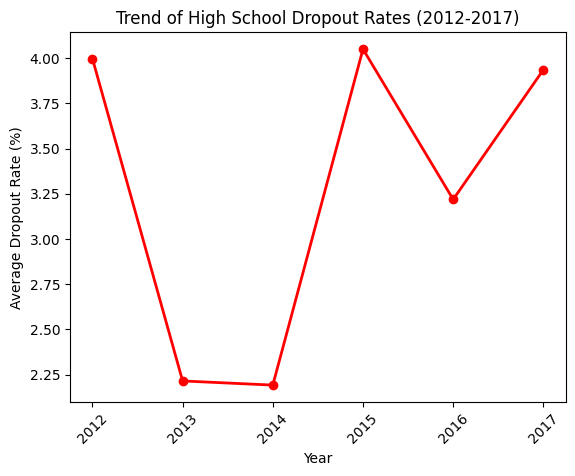

In [ ]:
## 4. Line Chart: Trend of High School Dropout Rates (2012-2017) 
dropout_trend = CrimeBal.groupby("CrimeYear")["Dropout"].mean()

# Plot the line chart
plt.plot(dropout_trend.index, dropout_trend.values, marker="o", linestyle="-", color="red", linewidth=2, markersize=6)
plt.xlabel("Year")
plt.ylabel("Average Dropout Rate (%)")
plt.title("Trend of High School Dropout Rates (2012-2017)")
plt.xticks(rotation=45)

plt.show()

The line graph shows the change in the high school dropout rate from 2012 to 2017, with a maximum value of 4.0 percent in 2012 and 2015 and a minimum of 2.2 percent in 2013 and 2014. Reports from the Maryland Department of Education and local news sources highlight this sharp decline from 2013 to 2014, especially among minority students. The fluctuation in dropout rates indicates instability in education levels, which may be linked to crime patterns. Higher dropout rates may indicate an economic decline, affecting higher crime rates in lower-income neighbourhoods.

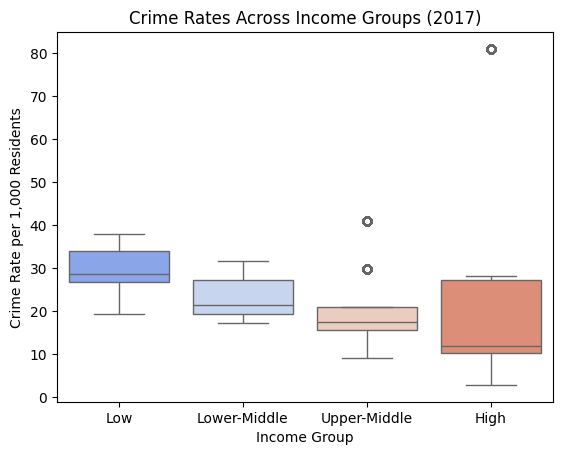

In [ ]:
## 5. Box Plot: Comparing crime rates across income groups in 2017

CrimeBal["CrimeYear"] = pd.to_numeric(CrimeBal["CrimeYear"], errors='coerce')
CrimeBal_2017 = CrimeBal[CrimeBal["CrimeYear"] == 2017].copy()
CrimeBal_2017.dropna(subset=["Income", "ViolentCrime"], inplace=True)

# Categorize income into quartiles
CrimeBal_2017["IncomeGroup"] = pd.qcut(CrimeBal_2017["Income"], q=4, labels=["Low", "Lower-Middle", "Upper-Middle", "High"])

# Create the box plot
sns.boxplot(x="IncomeGroup", y="ViolentCrime", hue="IncomeGroup", data=CrimeBal_2017, palette="coolwarm", legend=False)
plt.xlabel("Income Group")
plt.ylabel("Crime Rate per 1,000 Residents")
plt.title("Crime Rates Across Income Groups (2017)")
plt.grid(axis='y', linestyle='', alpha=0.7)

plt.show()

This box plot compares violent crime rates across different income groups. Low-income areas have the highest median violent crime rate, around 28 per 1000 residents, while high-income neighbourhoods have a lower median, below 15 per 1000 residents. However, the wide distribution range, especially in high-income neighbourhoods(outliers above 80), highlights differences in the distribution of crime. This raises the question of whether these high-crime outliers link to specific downtown neighbourhoods, which requires further investigation.

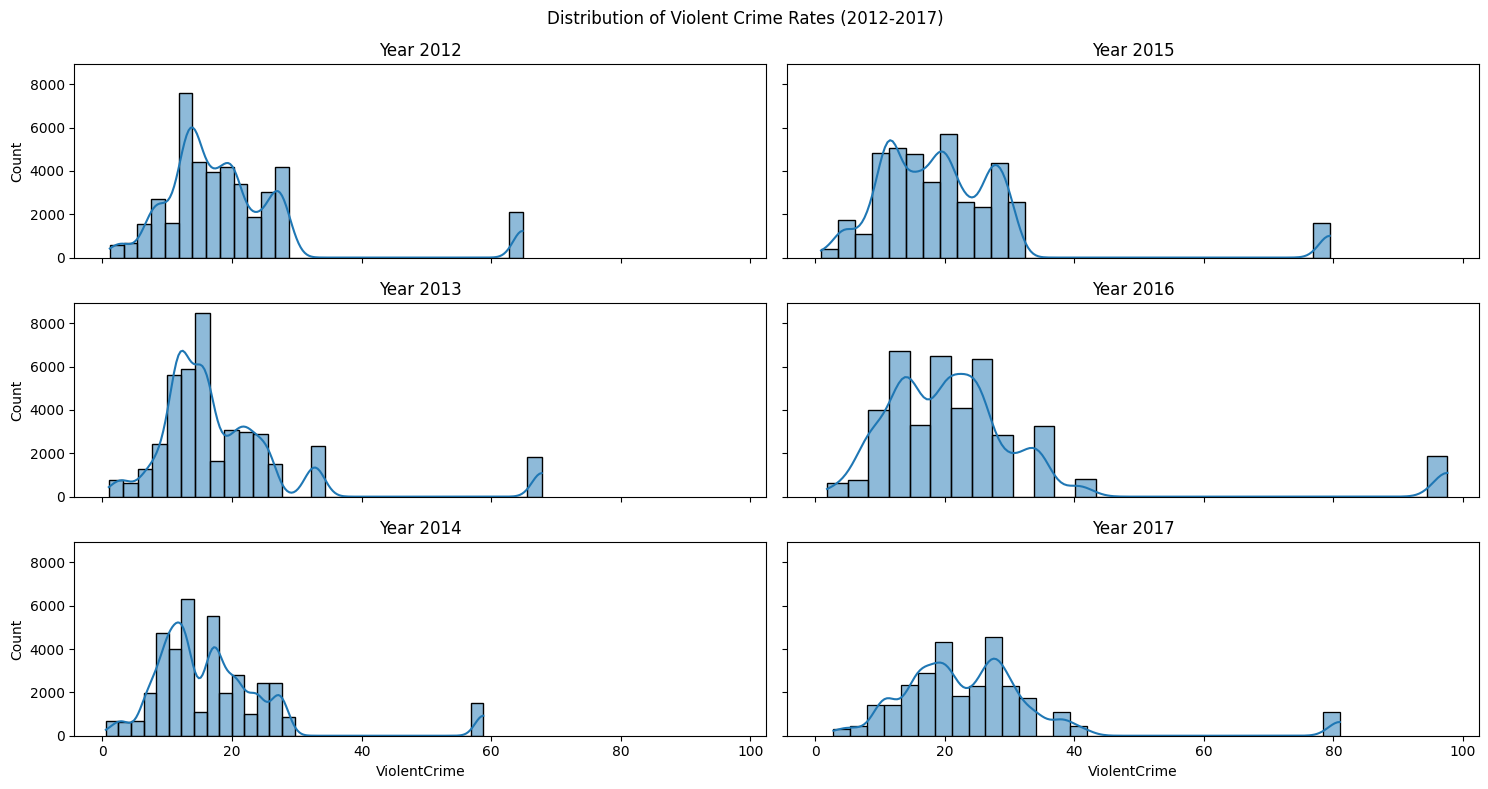

In [ ]:
#6. Side-by-Side Histograms for Violent Crime (2012-2017)
CrimeBal["CrimeYear"] = pd.to_numeric(CrimeBal["CrimeYear"], errors='coerce')
years = [2012, 2013, 2014, 2015, 2016, 2017]
fig, axes = plt.subplots(3, 2, figsize=(15, 8), sharex=True, sharey=True)
fig.suptitle('Distribution of Violent Crime Rates (2012-2017)')

for i, year in enumerate(years):
    ax = axes[i%3, i//3]
    sns.histplot(CrimeBal[CrimeBal['CrimeYear'] == year]['ViolentCrime'], bins=30, kde=True, ax=ax)
    ax.set_title(f"Year {year}")

plt.tight_layout()
plt.show()

These histograms show the distribution of violent crime from 2012 to 2017, allowing the comparison of violent crime intensity across the time. Crime rates peak around 20 per 1000 residents, and some years show more significant variability, with extremes approaching 80. The fact that violent crime rates remain stable in the long term illustrates that systemic problems like income gaps sustain crime rates rather than short-term fluctuations in economic conditions.

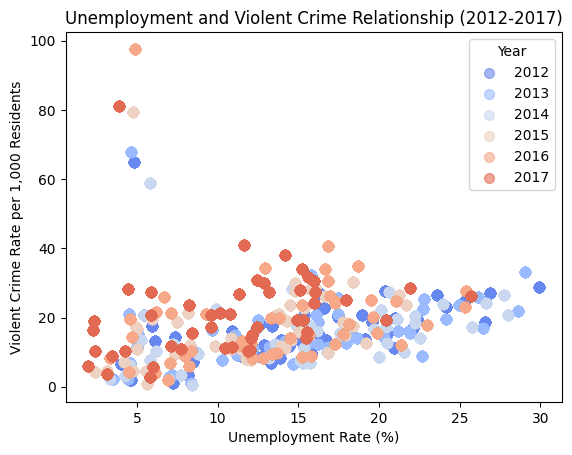

In [ ]:
# 7. Scatter Plot: Relationship Between Unemployment & Violent Crime

CrimeBal["Unemployment"] = pd.to_numeric(CrimeBal["Unemployment"], errors="coerce")
CrimeBal["ViolentCrime"] = pd.to_numeric(CrimeBal["ViolentCrime"], errors="coerce")
CrimeBal["CrimeYear"] = pd.to_numeric(CrimeBal["CrimeYear"], errors="coerce")
CrimeBal = CrimeBal.dropna(subset=["Unemployment", "ViolentCrime", "CrimeYear"])

years = list(range(2012, 2018))
colors = sns.color_palette("coolwarm", len(years))

# Plot scatter points for each year
for i, year in enumerate(years):
    subset = CrimeBal[CrimeBal["CrimeYear"] == year]
    plt.scatter(subset["Unemployment"], subset["ViolentCrime"], 
                alpha=0.6, s=50, color=colors[i], label=str(year))

plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Violent Crime Rate per 1,000 Residents")
plt.title("Unemployment and Violent Crime Relationship (2012-2017)")
plt.legend(title="Year")

plt.show()

This scatter plot shows the relationship between unemployment and violent crime from 2012 to 2017. There is a strong positive relationship between these two, with crime sharply rising as unemployment rises, reaching nearly 100 per 1000 residents at maximum. This consistent trend over the years shows that unemployment is also a significant factor in violent crime.

## 2. Project 2

### 2.1 The Message

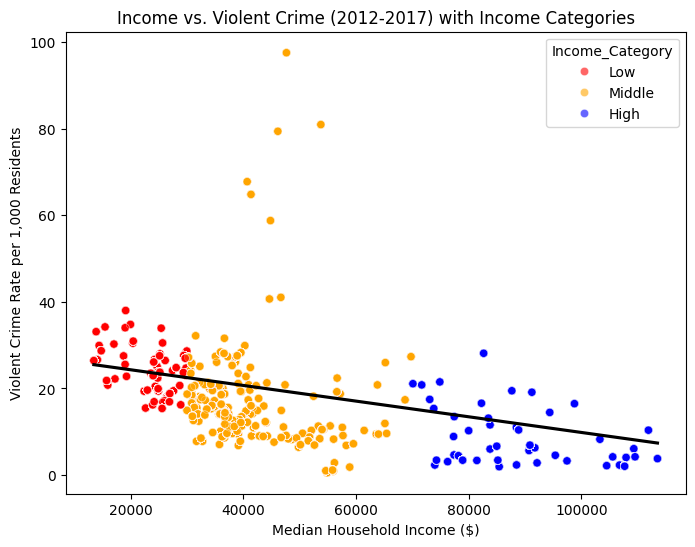

In [ ]:
df = CrimeBal.copy()

df['Income_Category'] = pd.cut(df['Income'],
                               bins=[0, 30000, 70000, float('inf')],
                               labels=['Low', 'Middle', 'High'])

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Income'], 
    y=df['ViolentCrime'], 
    hue=df['Income_Category'], 
    palette={'Low': 'red', 'Middle': 'orange', 'High': 'blue'}, 
    alpha=0.6
)
sns.regplot(
    x=df['Income'], 
    y=df['ViolentCrime'], 
    scatter=False, 
    color="black"
)

plt.xlabel("Median Household Income ($)")
plt.ylabel("Violent Crime Rate per 1,000 Residents")
plt.title("Income vs. Violent Crime (2012-2017) with Income Categories")

plt.savefig("Income_vs_Crime.png", dpi=300, bbox_inches='tight') 

plt.show()

Low-income neighbourhoods have significantly higher rates of violent crime rate, while high-income neighbourhoods typically have crime rates below 20 per 1000 residents. The negative relationship between income and violent crime rate almost remains constant, but the extreme outliers in middle-income areas suggest additional impacting factors.

### 2.2 Maps and Interpretations

In [41]:
neighborhood_counts = CrimeBal.groupby('Neighborhood').size().reset_index(name='count')
neighborhood_counts.rename(columns={'Neighborhood': 'Name'}, inplace=True)

In [42]:
# download baltimore map
baltimorecsa = gpd.read_file("Community_Statistical_Areas_(CSAs)__Reference_Boundaries.zip")
baltimorensa = gpd.read_file("Neighborhood_Statistical_Area_(NSA)_Boundaries.zip")

baltimorecsa.to_crs(epsg=4326, inplace=True)
baltimorensa.to_crs(epsg=4326, inplace=True)

### Map 1: Violent Crime rate in Baltimore (Y)

C:\Users\27250\AppData\Local\Temp\ipykernel_4308\3823258075.py:31: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\27250\AppData\Local\Temp\ipykernel_4308\3823258075.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


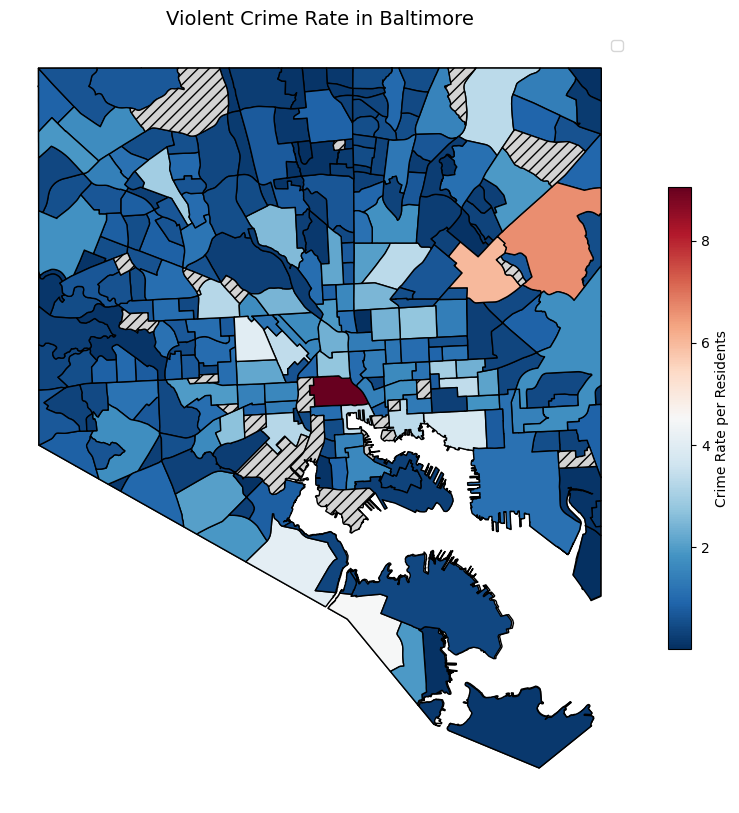

In [ ]:
# plot the map
fig, gax = plt.subplots(figsize=(10, 10))

baltimorecsa.plot(ax=gax, edgecolor="black", color="white")

# merge vltcrim with baltimorecsa on 'CSA2020'
baltimorensa = baltimorensa.merge(neighborhood_counts, left_on='Name', right_on='Name', how='left')

baltimorensa['CrimeRatePerPerson'] = baltimorensa['count'] / 1000
# Find max and min of Crime Rate Per Person
max_rate = baltimorensa['CrimeRatePerPerson'].max()
min_rate = baltimorensa['CrimeRatePerPerson'].min()


# plot colors on column '2021'
baltimorensa.plot(ax=gax, edgecolor="black", column='CrimeRatePerPerson', legend=True, cmap='RdBu_r',
                  legend_kwds={"label": "Crime Rate per Residents", "shrink": 0.6},
                  vmin=min_rate, vmax=max_rate,
                  missing_kwds={"color": "lightgrey", "edgecolor": "black", "hatch": "///", "label": "Missing values"})

gax.set_title("Baltimore Map")
gax.set_xlabel("Longitude")
gax.set_ylabel("Latitude")

gax.spines["top"].set_visible(False)
gax.spines["right"].set_visible(False)

gax.set_title("Violent Crime Rate in Baltimore", fontsize=14)

plt.axis("off")  
plt.legend()
plt.show()

This map shows the violent crime rate per capita in Baltimore, the dependent variable(Y) in the research question, highlighting areas with a high crime rate. Downtown has the highest crime rate, with more than 8 crimes per resident, and there are some unexpectedly high crime rates in northeastern communities. The map is based on community-level data and has some missing values. This map highlights the disproportionate crime rate in specific communities, reinforcing the link between crime burden and population density.

### Map 2: Income Level in Baltimore (main X)

C:\Users\27250\AppData\Local\Temp\ipykernel_4308\178776403.py:19: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\27250\AppData\Local\Temp\ipykernel_4308\178776403.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


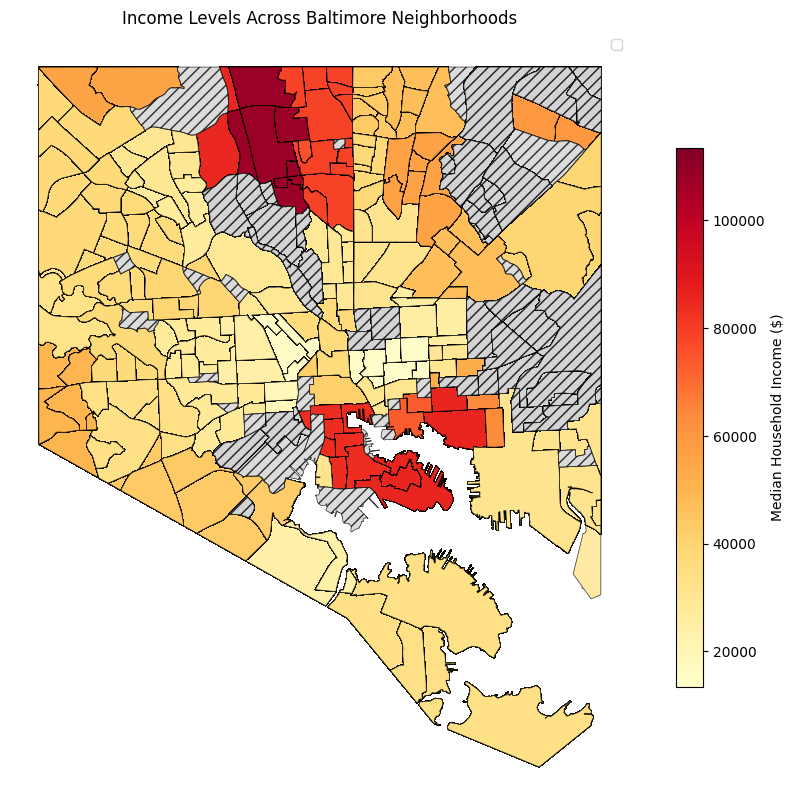

In [ ]:
CrimeBal_2 = CrimeBal.copy()
baltimorensa_2 = baltimorensa.copy()

CrimeBal.rename(columns={'Neighborhood': 'Name'}, inplace=True)  # Adjust column names if needed

# Merge CrimeBal income data with Baltimore shapefile
baltimore_gdf = baltimorensa_2.merge(CrimeBal[['Name', 'Income']], on='Name', how='left')


fig, ax = plt.subplots(figsize=(12, 10))

# Plot the heatmap for income levels
baltimore_gdf.plot(column='Income', cmap='YlOrRd', edgecolor="black", linewidth=0.5,
                   legend=True, legend_kwds={"label": "Median Household Income ($)", "shrink": 0.7},
                   alpha=0.8, ax=ax, missing_kwds={"color": "lightgrey", "edgecolor": "black", "hatch": "///", "label": "Missing values"})

ax.set_title("Income Levels Across Baltimore Neighborhoods")

plt.legend()
plt.axis("off")  
plt.show()

This heat map shows the median household income earned in one year by neighbourhood in Baltimore. Dark red regions indicate the neighbourhoods with the highest income level (over 10000 dollars), and the light-yellow regions show the low-income neighbourhoods (under 20000 dollars). This dataset is based on the community level without obvious missing values. The income gap is clear, showing that Baltimore's northwest and downtown areas have higher income levels and lower income levels in the south and southeast regions. Combined with Map 1, the pattern is almost consistent with the economic theory that lower-income neighbourhoods have higher crime rates, reinforcing the impact of economic disparity on crime distribution. However, some mid-level income areas also have unexpectedly high violent crime rates, which may be investigated later.

### Map 3: Crime Density & CitiWatch Cameras 

C:\Users\27250\AppData\Local\Temp\ipykernel_4308\335900873.py:48: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


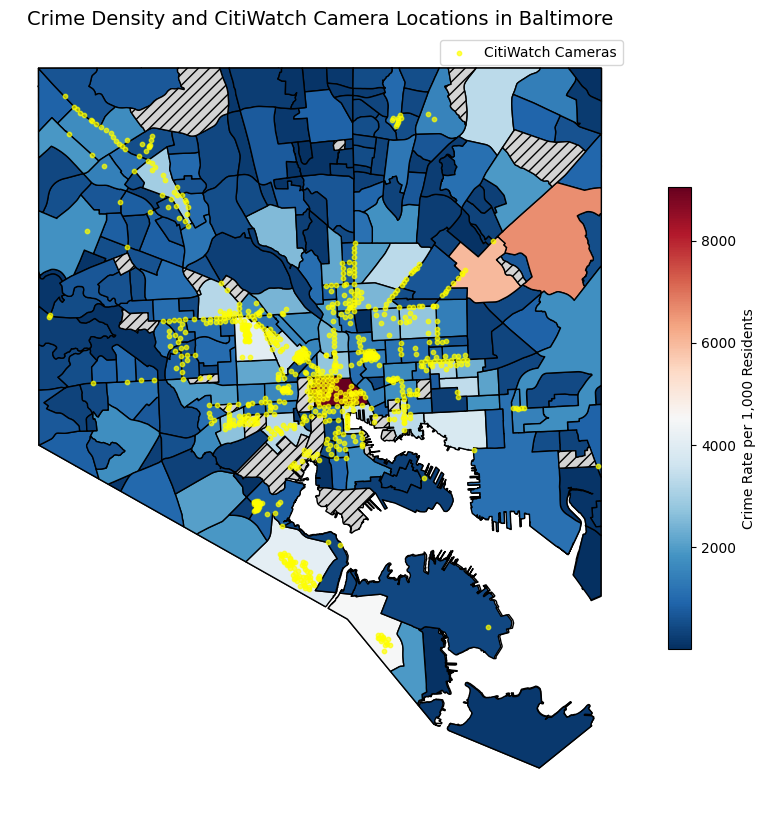

In [ ]:
# plot the map
fig, gax = plt.subplots(figsize=(10, 10))

baltimorecsa.plot(ax=gax, edgecolor="black", color="white")

# merge vltcrim with baltimorecsa on 'CSA2020'
baltimorensa = baltimorensa.merge(neighborhood_counts, left_on='Name', right_on='Name', how='left')

if 'count_x' in baltimorensa.columns:
    baltimorensa.rename(columns={'count_x': 'count'}, inplace=True)
if 'count_y' in baltimorensa.columns:
    baltimorensa.drop(columns=['count_y'], inplace=True)

# find max min of column 2021
max_count = baltimorensa['count'].max()
min_count = baltimorensa['count'].min()

# plot colors on column '2021'
baltimorensa.plot(ax=gax, edgecolor="black", column='count', legend=True, cmap='RdBu_r',
                  legend_kwds={"label": "Crime Rate per 1,000 Residents", "shrink": 0.6},
                  vmin=min_count, vmax=max_count,
                  missing_kwds={"color": "lightgrey", "edgecolor": "black", "hatch": "///", "label": "Missing values"})

gax.set_title("Baltimore Map")
gax.set_xlabel("Longitude")
gax.set_ylabel("Latitude")

gax.spines["top"].set_visible(False)
gax.spines["right"].set_visible(False)

# --- Add CitiWatch Camera Locations (Overlay as Points) ---
# Load CitiWatch Camera Data
camera_gdf = gpd.GeoDataFrame(camera_data, geometry=gpd.points_from_xy(camera_data.X, camera_data.Y))
camera_gdf.set_crs(epsg=2248, inplace=True)
camera_gdf = camera_gdf.to_crs(epsg=4326)

# Plot CitiWatch Cameras
camera_gdf.plot(
    ax=gax, 
    # not red nor blue light color
    color='yellow',
    markersize=10,  # Adjust size for visibility
    alpha=0.7, 
    label="CitiWatch Cameras"
)

gax.set_title("Crime Density and CitiWatch Camera Locations in Baltimore", fontsize=14)
plt.legend()
plt.axis("off") 
plt.show()

This map shows the distribution of the violent crime density per 1000 residents and overlays the location of Citywatch cameras throughout Baltimore. The high-crime areas, especially the downtown area, have crime rates of more than 8000 per 1000 residuals, while low-crime areas have crime rates of less than 2000. Surveillance cameras are concentrated in high-crime areas, but gaps remain in some high-crime-rate neighbourhoods. This aligns with the previous finding that higher crime in low-income areas is due to limited economic conditions. Geographic units are community-level data. The dataset is clean and well-defined, but some neighbourhoods (shadow areas) have missing values. The relationship between crime density and surveillance distribution shows the target policing strategy but also raises the question: Is the high crime rate caused/deterred by cameras, or are they placed in areas already exercising high crime rates? Investigate the unusual regions with extremely high crime rates but low camera density to discuss this phenomenon and take measures to improve.

### Map 4: Crime-to-Income Ratio and Socioeconomic Risk Factors

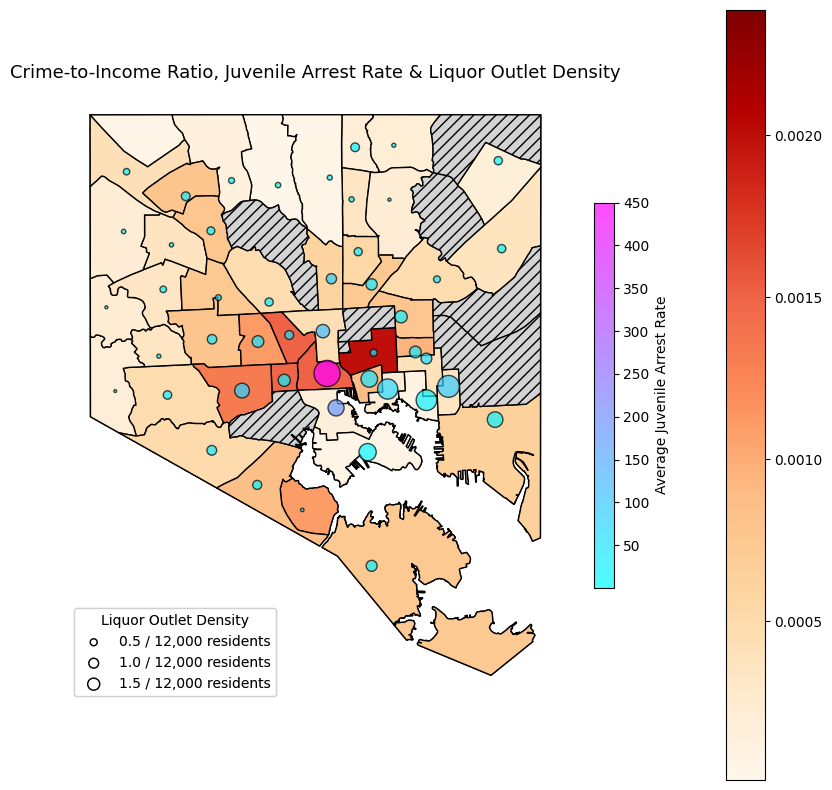

In [ ]:
# STEP 1: Aggregate data
grouped = CrimeBal.groupby("CSA2020").agg({
    "JuvenileArrestRate": "mean",
    "LiquorOutletdensity": "mean",
    "Longitude": "mean",
    "Latitude": "mean"
}).reset_index()

# STEP 2: Base map
fig, gax = plt.subplots(figsize=(10, 10))
baltimorecsa.plot(ax=gax, edgecolor="black", color="white")

# Calculate CIR
CrimeBal["CIR"] = CrimeBal["ViolentCrime"] / CrimeBal["Income"]
miniCrimeBal = CrimeBal.drop_duplicates(subset='CSA2020', keep='first')
baltimorecsa = baltimorecsa.merge(miniCrimeBal[['CSA2020', 'CIR']], on='CSA2020', how='left')

baltimorecsa.plot(
    ax=gax, 
    column="CIR", 
    cmap="OrRd", 
    edgecolor="black", 
    legend=True,
    vmin=CrimeBal["CIR"].min(), 
    vmax=CrimeBal["CIR"].max(),
    missing_kwds={"color": "lightgrey", "edgecolor": "black", "hatch": "///", "label": "Missing values"}
)

# STEP 3: Overlay dots with color = Juvenile Arrest Rate, size = Liquor Outlet Density
sc = gax.scatter(
    grouped["Longitude"], grouped["Latitude"],
    c=grouped["JuvenileArrestRate"],
    s=grouped["LiquorOutletdensity"] * 50,  
    cmap="cool", 
    edgecolors="black",
    alpha=0.7,
    label="Juvenile Arrest Rate & Liquor Outlet Density"
)

# STEP 4: Add colorbar
cbar = plt.colorbar(sc, ax=gax, shrink=0.5)
size_legend_vals = [0.5, 1.0, 1.5] 
size_scale = 50  

# Create dummy legend handles
size_handles = [
    plt.scatter([], [], s=val*size_scale, edgecolors='black', facecolors='none', label=f"{val} / 12,000 residents")
    for val in size_legend_vals
]

legend1 = gax.legend(
    handles=size_handles,
    title="Liquor Outlet Density",
    loc="lower left", 
    frameon=True
)

gax.add_artist(legend1)
cbar.set_label("Average Juvenile Arrest Rate")

gax.set_title("Crime-to-Income Ratio, Juvenile Arrest Rate & Liquor Outlet Density", fontsize=13)
plt.axis("off")
plt.show()

This map shows the Crime Burden (CIR), a crime to ration income, to explore additional socioeconomic risk factors, including the mortgage foreclosure rate, juvenile arrest rate and the Liquor outlet density in Baltimore. Areas with high CIR have high foreclosure rates, juvenile arrest rates and liquor outlet densities, linking economic depression in Baltimore. Areas with CIR above 0.002 tend to overlap with high foreclosure rates and liquor outlet density, supporting the social environment factors, which reinforce that economic distress will lead to violent crime. These data are also presented at the community level. In some areas, the concentration of juvenile arrests is extremely high, up to 450 per 1000 juveniles, alongside a high density of liquor outlets (more than 8 per 1000 residents), driving the crime condition. This map shows some outliers for the northeast and south regions, with lower socioeconomic risk factors, but the CIR is high. The relationship between economic instability and crime is consistent with economic theory, which is the theory of social disorder and criminal environment.

### 2.3 Regression Table

### Regression Table 1 - Violent Crime vs Socioeconomic Factors

In [ ]:
# Step 1: Convert date and extract month
CrimeBal['CrimeDate'] = pd.to_datetime(CrimeBal['CrimeDate'])
CrimeBal['YearMonth'] = CrimeBal['CrimeDate'].dt.to_period('M')

# Step 2: Aggregate monthly violent crime per neighborhood
monthly_crime = (
    CrimeBal.groupby(['CSA2020', 'YearMonth'])['ViolentCrime']
    .sum()
    .reset_index()
)

# Step 3: Aggregate socioeconomic variables (mean per month per neighborhood)
monthly_features = (
    CrimeBal.groupby(['CSA2020', 'YearMonth'])[
        ['Income', 'Unemployment', 'Dropout', 'MortgageForeclosure', 'LiquorOutletdensity']
    ]
    .mean()
    .reset_index()
)

# Step 4: Merge datasets
df = pd.merge(monthly_crime, monthly_features, on=['CSA2020', 'YearMonth'])

# Step 5: Feature engineering
df['const'] = 1

# Step 6: Regression models
X1 = ['const', 'Income']
X2 = ['const', 'Income', 'Unemployment']
X3 = ['const', 'Income', 'Unemployment', 'Dropout', 'MortgageForeclosure']
X4 = ['const', 'Income', 'Unemployment', 'Dropout', 'MortgageForeclosure', 'LiquorOutletdensity']

reg1 = sm.OLS(df['ViolentCrime'], df[X1], missing='drop').fit()
reg2 = sm.OLS(df['ViolentCrime'], df[X2], missing='drop').fit()
reg3 = sm.OLS(df['ViolentCrime'], df[X3], missing='drop').fit()
reg4 = sm.OLS(df['ViolentCrime'], df[X4], missing='drop').fit()

# Step 7: Results summary
info_dict={'R-squared' : lambda x: f"{x.rsquared:.2f}", 
           'No. observations' : lambda x: f"{int(x.nobs):d}"}

results_table = summary_col(results=[reg1, reg2, reg3, reg4],
                            float_format='%0.2f',
                            stars=True,
                            model_names=['Model 1', 'Model 2', 'Model 3', 'Model 4'],
                            info_dict=info_dict,
                            regressor_order=['const', 'Income', 'Unemployment', 'Dropout',
                                             'MortgageForeclosure', 'LiquorOutletdensity'])

# Optional: Stargazer view
stargazer = Stargazer([reg1, reg2, reg3, reg4])
HTML(stargazer.render_html())


The regression table shows a statistically significant but not economically significant negative relationship between income and violent crime, with each \$1000 increase in income reducing violent crime by 4.7 units per community (Model 4). Aggregating the crime data by the community on a monthly basis reduces individual-level noise. The results show that liquor outlet density had a significantly positive association (788.1), enhancing the effect of social environment factors on the crime rate. The unexpectedly negative impact of unemployment and mortgage foreclosure reduces the crime rate (usually, it should be positive), possibly due to lower residential density, which reduces potential victims. The dropout coefficient decreased from 59.3 to -99.2, and the increasing unemployment coefficient indicated interaction or multicollinearity. 

### Regression Table 2 - Violent Crime: Income level and Unemployment

In [ ]:
df = CrimeBal.copy()

# Add constant term to dataset
df['const'] = 1

# make single incomedummy from income
threshold = df['Income'].median()
df['IncomeDummy'] = (df['Income'] > threshold).astype(int)

# making binned dummies
df['IncomeBin'] = pd.cut(df['Income'],
                          bins=[0, 30000, 60000, float('inf')],
                          labels=['IncomeLow','IncomeMid','IncomeHigh'])

# Create Dummy Variables
dummies = pd.get_dummies(df['IncomeBin'], drop_first=False)  # if true drops 1st cat (alphabetically) to avoid dummy variable trap
dummies = dummies.astype(int) #convert from T/F to 1/0
df = pd.concat([df, dummies], axis=1)
df.drop(columns=['IncomeBin', 'IncomeLow'], inplace=True)

# Model 0: benchmark
X0 = df[['Unemployment']]
X0 = sm.add_constant(X0)
# Model 1: levels
X1 = df[['Unemployment', 'IncomeMid', 'IncomeHigh']]
X1 = sm.add_constant(X1)
# Model 2: Unemployment * IncomeMid
df['Unemployment_IncomeMid'] = df['Unemployment'] * df['IncomeMid']
df['Unemployment_IncomeHigh'] = df['Unemployment'] * df['IncomeHigh']
X2 = df[['Unemployment', 'IncomeMid','IncomeHigh', 'Unemployment_IncomeMid']]
X2 = sm.add_constant(X2)
# Model 3: Unemployment * IncomeHigh
X3 = df[['Unemployment', 'IncomeMid','IncomeHigh', 'Unemployment_IncomeHigh']]
X3 = sm.add_constant(X3)
y = df['ViolentCrime']


model0 = sm.OLS(y, X0).fit()
model1 = sm.OLS(y, X1).fit()
model2 = sm.OLS(y, X2).fit()
model3 = sm.OLS(y, X3).fit()

# Display the Regression Results using Stargazer
stargazer = Stargazer([model0 ,model1, model2, model3])

# Set the same order of variables for all regressions
stargazer.covariate_order(['const', 'Unemployment', 'IncomeMid', 'IncomeHigh', 'Unemployment_IncomeMid', 
                         'Unemployment_IncomeHigh'])
stargazer.title("Violent Crime: Income level and Unemployment")
stargazer.custom_columns(["Model 0","Model 1", "Model 2", "Model 3"], [1 , 1, 1, 1])


# Output the HTML representation of the regression table
html_output = stargazer.render_html()

HTML(html_output)

This regression table shows the relationship between income levels, unemployment and violent crime in Baltimore. The negative coefficients on IncomeMid and IncomeHigh in Model 1 support the economic theory that a higher income level has lower violent crime rates, consistent with Becker’s (1968) economic model on criminal motivation. Model 3 shows that high-income neighbourhoods had an average of 32.158 fewer violent crimes per 1000 residents than low-income neighbourhoods (baseline). The positive interaction between unemployment and high income (0.652) indicates that unemployment increases violent crime, but the effect is less severe in wealthier areas. Conversely, the negative interaction between unemployment and income (-1.091) in Model 2 indicates unemployment substantially impacts crime in middle-income neighbourhoods. Model 2 has the more significant value of adjusted R², indicating stronger explanation power and additional interaction terms improve the model fit. Targeting unemployment in middle-income neighbourhoods may be most effective since sudden unemployment in previously stable lives creates greater feelings of anxiety, frustration, and injustice, potentially fueling crime.

### Regression Table 3 - Crime Policy, Social Environment, and Violent Crime

In [ ]:
df = CrimeBal.copy()
df['const'] = 1

df['Income_10k'] = df['Income'] / 10000

# Define independent variables for each model
X1 = df[['Income_10k', 'Unemployment', 'Dropout']]
X2 = df[['Income_10k', 'Unemployment', 'Dropout', 'LiquorOutletdensity']]
X3 = df[['Income_10k', 'Unemployment', 'Dropout', 'LiquorOutletdensity', 'JuvenileArrestRate', 'MortgageForeclosure']]

df['Income10k_Juvenile'] = df['Income_10k'] * df['JuvenileArrestRate']
df['Unemp_Juvenile'] = df['Unemployment'] * df['JuvenileArrestRate']
X4 = df[['Income_10k', 'Unemployment', 'Dropout', 'LiquorOutletdensity', 'JuvenileArrestRate', 'MortgageForeclosure', 'Income10k_Juvenile', 'Unemp_Juvenile']]

# Add constant term
X1 = sm.add_constant(X1)
X2 = sm.add_constant(X2)
X3 = sm.add_constant(X3)
X4 = sm.add_constant(X4)

# Define dependent variable
y = df['ViolentCrime']

# Merge all Xs and y into one DataFrame and clean NaNs/infs
full_df = pd.concat([X4, y], axis=1)
full_df = full_df.replace([np.inf, -np.inf], np.nan).dropna()

# Redefine your X and y for each model from the cleaned DataFrame
X1 = sm.add_constant(full_df[X1.columns])
X2 = sm.add_constant(full_df[X2.columns])
X3 = sm.add_constant(full_df[X3.columns])
X4 = sm.add_constant(full_df[X4.columns])
y = full_df[y.name]

# Run OLS regressions
model0 = sm.OLS(y, X1).fit()
model1 = sm.OLS(y, X2).fit()
model2 = sm.OLS(y, X3).fit()
model3 = sm.OLS(y, X4).fit()

stargazer = Stargazer([model0 ,model1, model2, model3])

stargazer.covariate_order(['const', 'Income_10k', 'Unemployment', 'Dropout', 'LiquorOutletdensity', 'JuvenileArrestRate', 
                         'MortgageForeclosure','Income10k_Juvenile', 'Unemp_Juvenile' ])
stargazer.title("Crime Policy, Social Environment, and Violent Crime")
stargazer.custom_columns(["Model 0","Model 1", "Model 2", "Model 3"], [1 , 1, 1, 1])


# Output the HTML representation of the regression table
html_output = stargazer.render_html()

HTML(html_output)

This regression table shows the impact of economic and social environmental factors on violent crime. Income_10k is used instead of the original income to improve interpretability and avoid coefficient rounding error, as using original income units results in a coefficient near zero. Income remains strongly negative, with a 10000 dollar increase in median income decreasing violent crime by 1.374 (Model 3). The coefficient of the unemployment rate becomes positively significant when additional variables are added, indicating that economic instability increases the risk of crime when other factors are considered. Dropout rates and juvenile arrest rates are increasing significantly, highlighting the importance of youth-related risks. Liquor outlet density remains positive, supporting the effect of social disorder, while foreclosure rates negatively impact crime, possibly due to lower population density. The interaction term (Unemp_Juvenile) is –0.006, indicating a complex and subtle effect in a society facing economic and youth crime. The coefficient of interaction between unemployment and juvenile arrest is most important since it reflects how economic pressures on young people can quickly deepen the risk of long-term crime activities and destroy a juvenile’s life.

### 2.3.2 Model Performance

In [1]:
from IPython.display import display, Math

display(Math(r"""
\begin{aligned}
\widehat{\text{Violent Crime Rate}}_i &= 13.872 
- 1.374 \cdot \text{Income10k}_i 
+ 0.430 \cdot \text{Unemployment}_i \\ 
&\quad + 0.736 \cdot \text{Dropout}_i
+ 0.302 \cdot \text{Liquor Outlet Density}_i \\ 
&\quad+ 0.250 \cdot \text{Juvenile Arrest Rate}_i 
- 1.849 \cdot \text{Mortgage Foreclosure}_i \\
&\quad - 0.017 \cdot \text{Income10k_Juvenile}_i
- 0.006 \cdot \text{Unemp_Juvenile}_i
\end{aligned}
"""))

<IPython.core.display.Math object>

These three regression tables were created to explore the correlation between income inequality and violent crime in Baltimore. The first table establishes a general range of socio-economic factors that impact crime, the second forces income levels and unemployment rate, highlights the effect of income factors in crime patterns, and the third table includes policy-relevant variables, like liquor export, juvenile crime and mortgage foreclosure and evaluates their interaction. The preferred model is model 3 in the Regression Table 3 because it includes key economic, social and policy-related variables that capture a more comprehensive view. This model also has the highest explanatory power (adjust R²), indicating a good model fit. Next, I will determine the relationship between foreclosure rates, unemployment, and income. They may be closely related, and this strong correlation between them could explain the unexpected negative effects of foreclosure rates since areas with high foreclosure rates may have already experienced a recession, reducing opportunities for crime.

## 3. Final Project

### 3.1 Potential Data to Scrape

In the web-scraping part, I used Selenium-based Web scraping to scrape the data from the 999 Suicide & Crisis Lifeline website (https://988min.org/mental-health-resources/?search_page=1). This website provides extensive, regularly updated dictionaries of mental health services in Baltimore, embedded in dynamic HTML content, so using traditional HTML-based web scrapping tools (such as BeautifulSoup) is insufficient since it will appear asynchronously as users scroll. This requires the automation technique of Selenium web scraping to interact with it and access the information. The API-based web scraping is also not accessible on this website, and there is no exportable or downloadable CSV/XLSX format, which further enhances the necessity of using Selenium.

The scraped data include over 2000 mental health institutions, with names, phone numbers, websites and addresses. This information is not available on other downloadable websites. I chose this data since it directly supports my research question, which explores the effect of income inequality on violent crime in Baltimore. Mental health service, particularly location data, acts as a confounding variable, correlating with socioeconomic conditions (like income and unemployment) and crime rates. This helps assess whether economic predictors can explain the crime rate alone or whether the social services on mental health impact this relationship. I will scrape these data and geocode addresses and overlay them on maps alongside income and crime data, which can inform some policy interventions beyond economic measures.

### 3.2 Potential Challenges

One of the major challenges I faced was that the data on this website loads dynamically, which made HTML-based web scraping methods ineffective. Additionally, although the website technically has API, it requires a secure access key that is not public. Therefore, I had to rely on Selenium to navigate each page manually. This method is very time-consuming. It takes more than a minute to load each page, and there are more than 200 pages so that a single scaping can take several hours. If something goes wrong during scraping, I have to restart and debug. For example, the page information is sometimes incomplete, so it may be out of a bug when I run the code. I have to use a more complex ‘try except’ to fix this exception. To keep the data up to date, I need to re-run these codes every six months to update the information.

### 3.3 Scraping Data from a Website

In [28]:
driver = webdriver.Edge()


longWait = WebDriverWait(driver, 2400)
shortWait = WebDriverWait(driver, 300)


MHServices = []

In [ ]:
def scrapePage(driver, index = 1):
    driver.get(f"https://988min.org/mental-health-resources/?distance=51&search_page={index}&zip=21201")


    # Wait for element class="ms-search__results", and  "ms-search-results" to appear
    longWait.until(EC.presence_of_all_elements_located((By.CSS_SELECTOR, 
                                                        ".ms-search-results.ms-search__results .ms-resource-item")))
    time.sleep(0.1)
    resources = driver.find_elements(By.CSS_SELECTOR, ".ms-search-results.ms-search__results .ms-resource-item")
    for resource in resources:

        shortWait.until(EC.presence_of_element_located((By.CSS_SELECTOR, ".ms-resource-item__header h4 a")))
        title = resource.find_element(By.CSS_SELECTOR, ".ms-resource-item__header h4 a").text

        shortWait.until(EC.presence_of_element_located((By.CLASS_NAME, "ms-resource-item__content")))
        content = resource.find_element(By.CLASS_NAME, "ms-resource-item__content")

        # For each class="ms-resource-item__tableitem" in content
        shortWait.until(EC.presence_of_all_elements_located((By.CLASS_NAME, "ms-resource-item__tableitem")))
        tableItems = resource.find_elements(By.CLASS_NAME, "ms-resource-item__tableitem")

        phone = ""
        website = ""
        address = ""

        for item in tableItems:
            name = item.find_element(By.CLASS_NAME, "ms-resource-item-label").text
            value = item.find_element(By.CLASS_NAME, "ms-resource-item-value").text

            match name:
                case "PHONE:":
                    phone = value
                case "WEBSITE:":
                    website = value
                case "ADDRESS:":
                    address = value

        MHServices.append([title, phone, website, address])

In [ ]:
# 209 pages
for i in range(1, 210):
    scrapePage(driver, i)


# Create a DataFrame from the list of lists
df_mh = pd.DataFrame(MHServices, columns=["Title", "Phone", "Website", "Address"])

# Save as CSV
df_mh.to_csv("MentalHealthServices.csv", index=False)

In the first part, I import the necessary libraries in the chunk, including Selenium’s WebDriver and configuration wait conditions, which set up a Microsoft Edge driver and two kinds of wait times (long and short) for different load times. In the second part, I use the scrapePage() function to use the driver to navigate to the dynamic URL and wait for the element with the class selector to load. This function collects the name, phone, website and address by iterating over HTML tags and adding this information to the list. In the third part, I run a loop called scrapePage() on all the pages on this website(209 pages). The captured data is put into a data frame and saved as a CSV file. These codes ensure the scraping of dynamic websites that simple HTMI or API-based technologies cannot handle.

### 3.4 Visualizing the Scraped Dataset

Visualization 1: Map - Mental Health Services Locations in Baltimore

C:\Users\27250\AppData\Local\Temp\ipykernel_4308\3629359175.py:40: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


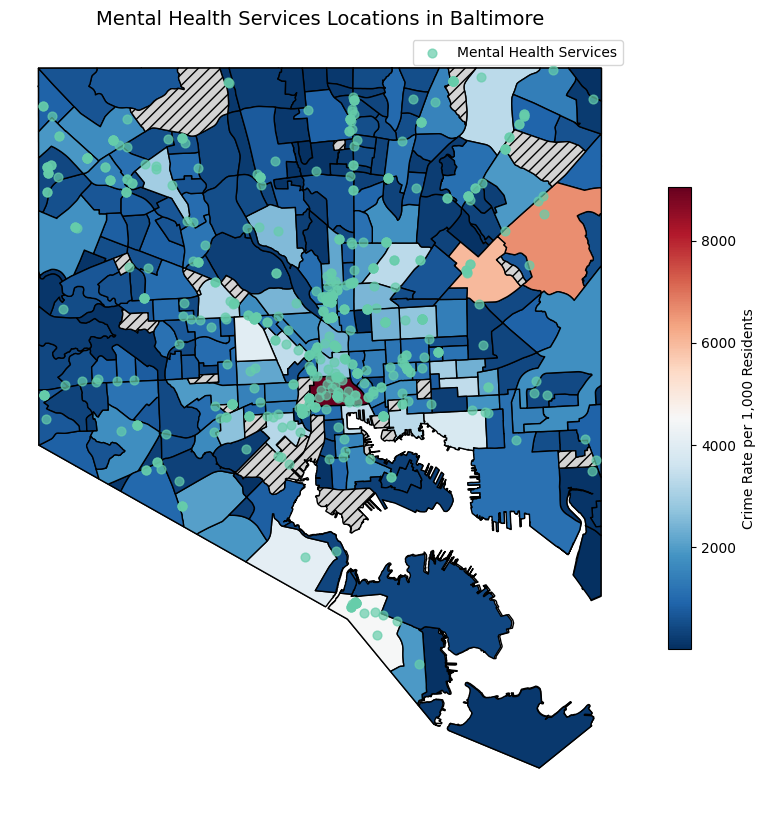

In [ ]:
# Filter only points that are physically inside Baltimore
mh_gdf = gpd.GeoDataFrame(
    mental_health,
    geometry=gpd.points_from_xy(mental_health.Longitude, mental_health.Latitude),
    crs="EPSG:4326"
)

mh_gdf = gpd.sjoin(mh_gdf, baltimorecsa, how='inner', predicate='within')

# Plot base map
fig, gax = plt.subplots(figsize=(10, 10))
baltimorecsa.plot(ax=gax, edgecolor="black", color="white")

baltimorensa = baltimorensa.merge(neighborhood_counts, on='Name', how='left')
max_count = baltimorensa['count'].max()
min_count = baltimorensa['count'].min()

baltimorensa.plot(
    ax=gax,
    edgecolor="black",
    column='count',
    legend=True,
    cmap='RdBu_r',
    legend_kwds={"label": "Crime Rate per 1,000 Residents", "shrink": 0.6},
    vmin=min_count, vmax=max_count,
    missing_kwds={"color": "lightgrey", "edgecolor": "black", "hatch": "///", "label": "Missing values"}
)

# Plot mental health service points
mh_gdf.plot(
    ax=gax,
    color="#66CDAA",
    markersize=40,
    alpha=0.7,
    label="Mental Health Services"
)

gax.set_title("Mental Health Services Locations in Baltimore", fontsize=14)

plt.legend()
plt.axis("off")
plt.show()

This map shows the distribution of the mental health services in Baltimore relative to neighbourhood-level violent crime rate. The darker red colour represents higher crime rates, and the green dots represent the locations for mental health services. The concentration of mental health services with high crime rates indicates a deliberate targeting area with greater need. However, the lack of mental health services in some peripheral communities with higher crime rates (southeast) suggests a potential gap in infrastructure service. In the economic aspect, this visualization connects the research questions by highlighting how the inequality in access to essential services such as mental health care simulates violent crime in low-income neighbourhoods. According to the economic theory of crime, mental health issues increase the likelihood of criminal behaviour, especially in economically depressed environments. The uneven distribution of mental health resources, especially in high-crime areas, highlights the need for policy interventions to expand access to mental health care to address income inequality and reduce violent crime.

Visualization 2: Bar Plot - Mental Health Service Density by Different Income Group

In [21]:
# 1. Counts the number of mental health services in each neighbourgood
gdf_mhs = gpd.GeoDataFrame(
    mental_health,
    geometry=gpd.points_from_xy(mental_health.Longitude, mental_health.Latitude),
    crs="EPSG:4326"
)

points_in_polygons = gpd.sjoin(gdf_mhs, baltimorecsa, predicate="within", how="left")

# Count how many points fall within each polygon by grouping on the CSA index provided by the join
counts = points_in_polygons.groupby('index_right').size()

# Add the counts back to the baltimorecsa GeoDataFrame as a new column
baltimorecsa['mentalhealth_count'] = counts
baltimorecsa['mentalhealth_count'] = baltimorecsa['mentalhealth_count'].fillna(0).astype(int)

In [22]:
# 2. put the mental health counts and income into one dataset (not the meain dataset)
income = CrimeBal[['CSA2020', 'Income']].drop_duplicates()

# merge income and baltimorecsa on CSA2020 for income and Community for csa
baltimorecsa = baltimorecsa.merge(income, left_on='Community', right_on='CSA2020', how='left')

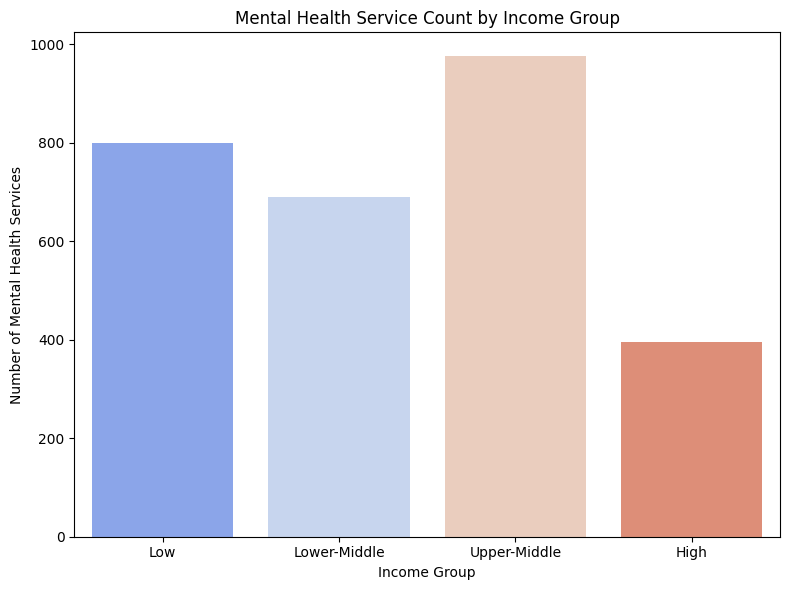

In [ ]:
# 3. Plot the bar plot
baltimorecsa_clean = baltimorecsa.dropna(subset=["Income", "mentalhealth_count"]).copy()

baltimorecsa_clean["IncomeGroup"] = pd.qcut(
    baltimorecsa_clean["Income"], 
    q=4, 
    labels=["Low", "Lower-Middle", "Upper-Middle", "High"]
)

bar_data = baltimorecsa_clean.groupby("IncomeGroup", observed=True)["mentalhealth_count"].sum().reset_index()

# Plot using hue and matching colors to scatter plot
plt.figure(figsize=(8, 6))
sns.barplot(data=bar_data, x="IncomeGroup", y="mentalhealth_count", hue="IncomeGroup", 
            palette="coolwarm", dodge=False, legend=False)

plt.title("Mental Health Service Count by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Number of Mental Health Services")

plt.tight_layout()
plt.show()

This bar plot shows the total number of mental health service locations across Baltimore neighbourhoods grouped by four different income levels. The upper-middle-income neighbourhoods have the highest number of mental health services, with nearly 1000, followed by low-income neighbourhoods, with about 800 and lower-middle-income neighbourhoods, with about 700. In contrast, the high-income communities have the fewest services, with fewer than 400. This distribution suggests that mental health services are more distributed in low and middle-income neighbourhoods, where the need is more significant due to the higher violent crime rate. There is a large gap between the upper-middle- and high-income groups with more than 580. The obvious difference in the accessibility of mental health services between different income groups raises problems about whether distribution is proportional to demand. This plot links to the research question by highlighting the uneven distribution of social infrastructure, a key component when considering how income inequality interacts with crime and vulnerability at the community level.

### 3.5 Regression Tree

#### 3.5.1 Preferred Regression

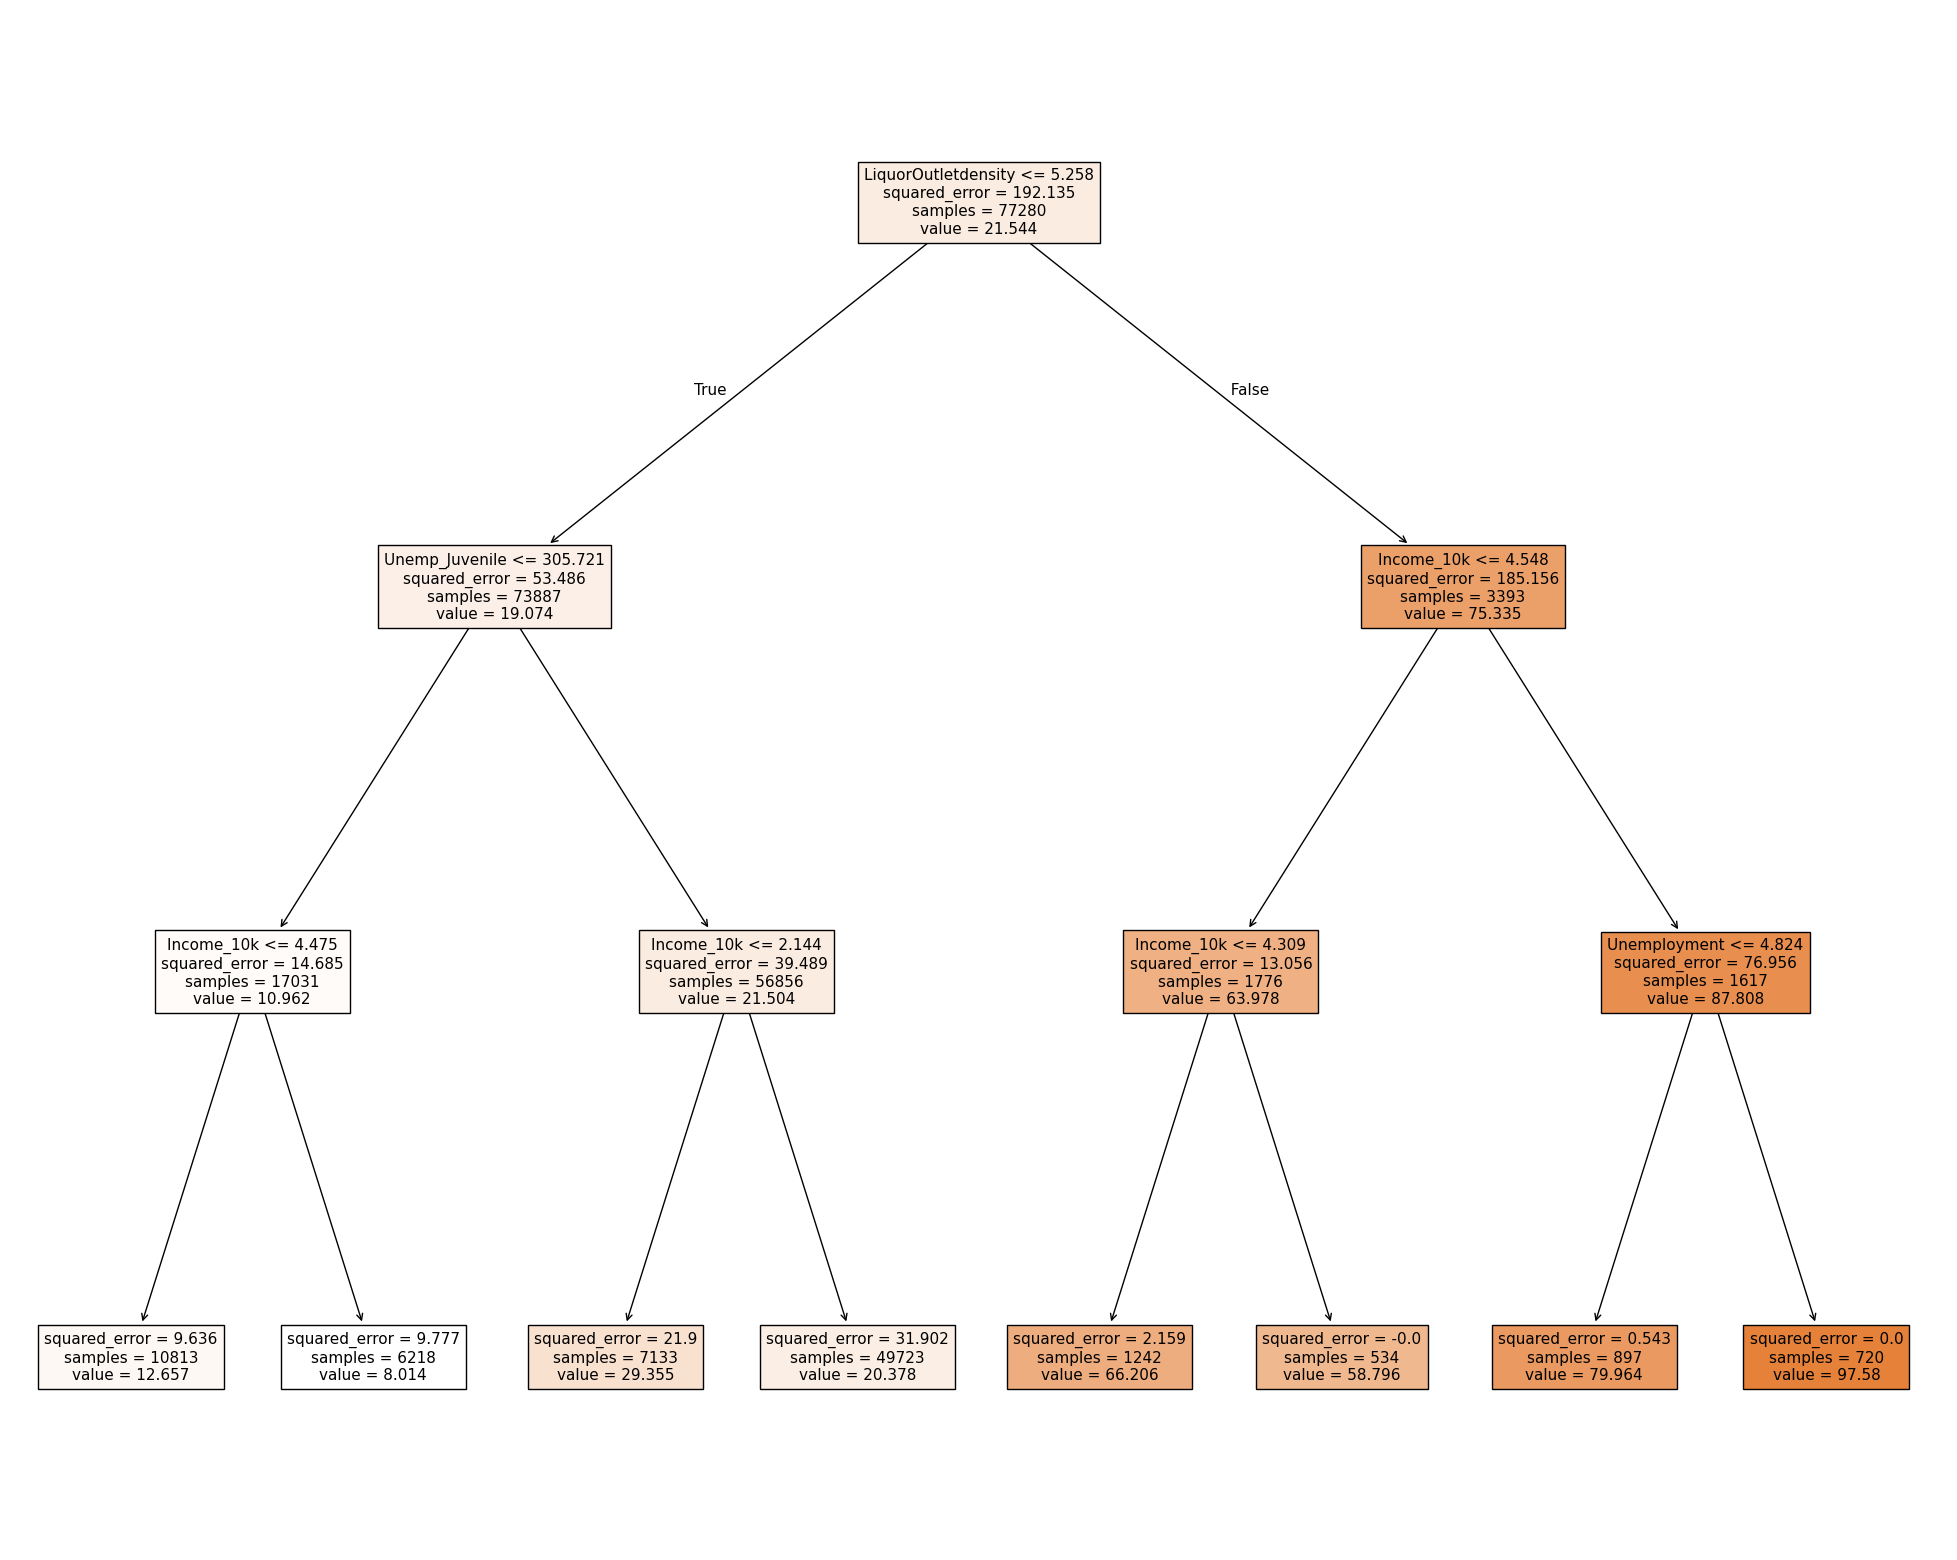

In [ ]:
CrimeBal = CrimeBal.dropna()
lr_model = linear_model.LinearRegression()
CrimeBal['Income_10k'] = CrimeBal['Income'] / 10000

CrimeBal['Income10k_Juvenile'] = CrimeBal['Income_10k'] * CrimeBal['JuvenileArrestRate']
CrimeBal['Unemp_Juvenile'] = CrimeBal['Unemployment'] * CrimeBal['JuvenileArrestRate']

X = CrimeBal[['Income_10k', 'Unemployment', 'Dropout', 'LiquorOutletdensity', 
              'JuvenileArrestRate', 'MortgageForeclosure', 'Income10k_Juvenile', 'Unemp_Juvenile']]
y = CrimeBal['ViolentCrime']

fitted_tree = tree.DecisionTreeRegressor(max_depth=3).fit(X,y)
fig = plt.figure(figsize=(25,20))
fig = tree.plot_tree(fitted_tree, feature_names=['Income_10k', 'Unemployment', 
                                                 'Dropout', 'LiquorOutletdensity', 'JuvenileArrestRate', 
                                                 'MortgageForeclosure', 'Income10k_Juvenile', 'Unemp_Juvenile'], 
                                                 filled=True)

This regression tree used the variables in my preferred OLS regression (Model 3 in Regression Table 3), focusing on income (in 10000 dollars), unemployment, the Liquor Outlet Density, and the interaction between Unemployment and Juvenile Arrest Rate. The tree selects variables and thresholds that minimize the residual sum of squares (RSS) at each split in predicting violent crime across neighbourhoods. The first split is Liquor Outlet Density, and neighbourhoods with less than 5.26 outlets per 12000 residents are on the left, with a lower average violent crime rate of 19.07 per 1000 residents, showing the strong impact of this factor. The second split is juvenile-related unemployment, with a cutoff value of -305.72. Neighbourhoods with an average income of less than 44750 dollars have 11 crimes compared with 8 for areas above the threshold. On the right of the tree, violent crime rises sharply in the higher liquor outlet density areas. The crime rate is as high as 97.6 crimes in the areas where the median income is less than 45480 dollars, and the unemployment rate is higher than 4.8 percent. Regularization parameters are applied to balance model complexity and overfitting. The ‘max_depth’ allows the tree to capture more variables but may lead to overfitting, and ‘min_samples_leaf’ is used to force the tree to create border splits, reducing noise but ignoring some factors in the data. This tree shows how a combination of economic and social risks can impact crime rates.

#### 3.5.2 Regression Tree with all of X variables

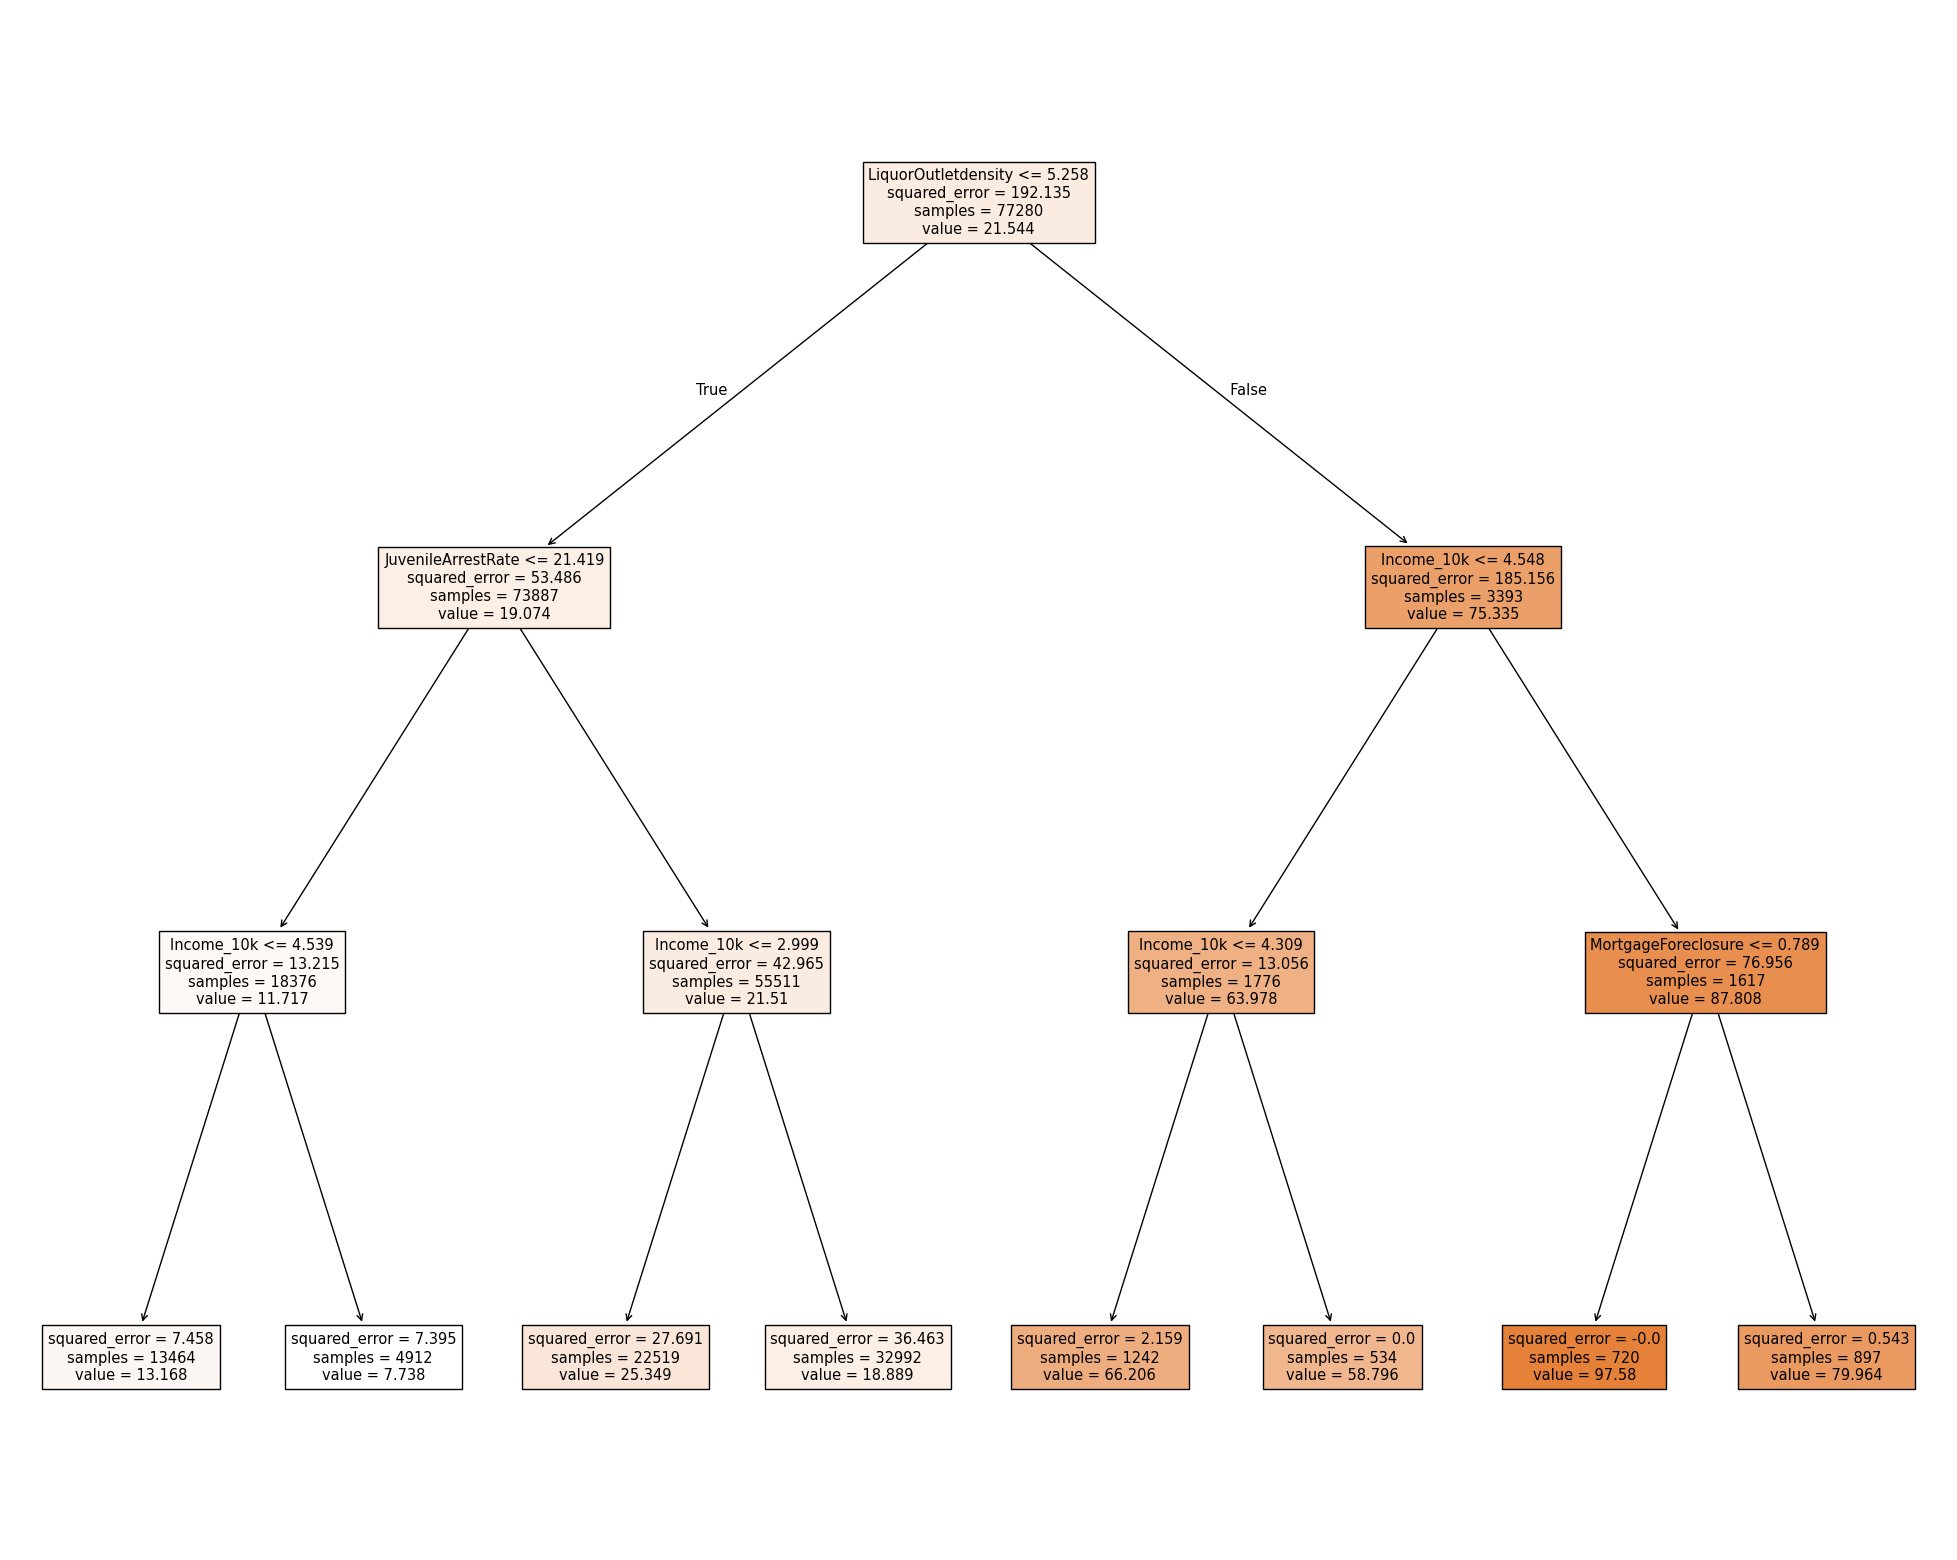

In [ ]:
CrimeBal = CrimeBal.dropna()
lr_model = linear_model.LinearRegression()
CrimeBal['Income_10k'] = CrimeBal['Income'] / 10000

X = CrimeBal[['Income_10k', 'Unemployment', 'Dropout', 'LiquorOutletdensity', 'JuvenileArrestRate', 'MortgageForeclosure']]
y = CrimeBal['ViolentCrime']

fitted_tree = tree.DecisionTreeRegressor(max_depth=3).fit(X,y)
fig = plt.figure(figsize=(25,20))
fig = tree.plot_tree(fitted_tree, feature_names=['Income_10k', 'Unemployment', 'Dropout', 'LiquorOutletdensity', 
                                                 'JuvenileArrestRate', 'MortgageForeclosure'], filled=True)

This regression tree uses all x variables, starting with liquor export density as the first split, showing that neighbourhoods with less than 5.25 liquor outlets per 12000 residents tend to have lower levels of violent crime. The second split is the juvenile arrest rate, and the areas with an arrest rate of less than 21.42 per 1000 juveniles have a lower crime rate. Income became the third key factor, and areas with income above 45390 dollars had the lowest crime rate of 13.17. The predicted crime rate increases in a lower-income area (below 29990 dollars). On the side of higher liquor outlet density, income and mortgage foreclosures become important. The highest crime rate is nearly 98 in neighbourhoods with a median income below 43090 dollars and foreclosure rates below 0.789. I didn't expect alcohol outlet density to dominate crime predictions, but it makes sense since alcohol may increase impulse violent crime, especially in economically strained communities.

#### 3.5.3 Comparison between Two Regression Tree

The regression tree of my preferred model has a lower squared error on key leaves, indicating more stable prediction and less overfitting. It also emphasizes economic theory, including the interaction effect between juvenile arrest and unemployment, which reflects social pressures. The full variable tree is informative but introduces a higher complexity, increasing interpretability but weakening prediction accuracy. I chose the preferred model tree because it balances the predictive accuracy and includes enough information with lower variance. It captures the core economic and social factors, making them consistent with the main focus of this research.

### 3.6 Random Forest

In [38]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,confusion_matrix, classification_report

# Calculate MSE
regr_RF = RandomForestRegressor(max_features=5, random_state=1).fit(X, y)
pred = regr_RF.predict(X)

mean_squared_error(y, pred)

4.325070842770867e-19

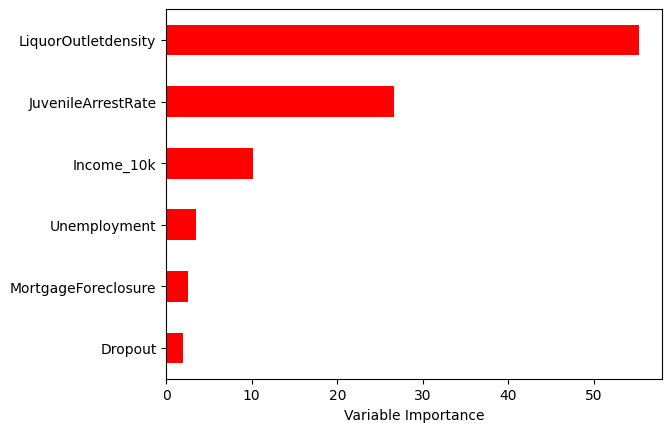

In [ ]:
# Importance Matrix
Importance = pd.DataFrame({'Importance':regr_RF.feature_importances_*100}, index=X.columns)
Importance.sort_values('Importance', axis=0, ascending=True).plot(kind='barh', color='r', )
plt.xlabel('Variable Importance')
plt.gca().legend_ = None

The Random Forest Importance Matrix shows that income level (main predictor) ranks only third to liquor outlet density and juvenile arrest rates. This result is a little surprising since income should be the main factor in explaining violent crime based on economic theory prediction. The lower ranking of income may reflect the interaction and non-linear effect, indicating that access to liquor and juvenile activity have a more direct impact on violent crime across neighbourhoods. Income still plays a role, but social factors may partly mediate its effect. For example, low-income neighbourhoods tend to have more liquor outlets and higher rates of juvenile arrest. This suggestion that income has a more indirect effect on crime highlights how income inequality can be a significant driver through social factors that lead to violent crime. This finding enhances the complexity of the determinants of crime by using the linear income effect and rounds out my regression findings.

### 3.7 OLS vs ML

OLS regression clearly shows that income level is a statistically significant predictor of violent crime with a negative coefficient across all the models. This supports the economic theory that higher incomes reduce criminal motivation. However, OLS shows the linearity relation, and the interaction effect is only shown if it is explicitly modelled. Instead, the regression tree automatically captures effects of nonlinear and conditional interaction. Moreover, the tree also indicates the thresholds for significant changes in the criminal rate and highlights the nested relationship. For example, it shows the predicted violent crime rate rises sharply when the median household income is below $45480, especially if there is a high density of liquor outlets and juvenile arrests, and how the economic pressures on juveniles impact crime when incomes are low. These interactions are not directly visible in the OLS results, showing the flexibility of the regression tree, which can capture conditional outcomes. While the tree may have overfitting risks, the regularization controls this issue, and the tree illustrates critical threshold value and a combination of risks that can help design targeted policy measurements that pure OLS regression cannot easily provide.

### 3.8 Conclusion

This paper explores how income inequality impacted violent crime rates significantly in Baltimore from 2012 to 2017. While the relationship between poverty and crime is well-documented, this study highlights the importance of economic and social factors in explaining violent crime at the community level. The findings suggest that income plays a significant role, but this relationship is not entirely linear and regulated by social and environmental factors, consistent with previous studies (MacDonald, 2015; Heagerty, 2010).

Regression trees and random forest models are used in this research to solve this nonlinear problem. Regression trees are particularly effective for identifying thresholds, potential interaction effects, and nested relationships without specifying these interactions in advance. For example, the tree shows that violent crime rates rise sharply only when both alcohol export density and youth unemployment exceed certain thresholds. Random forest improves prediction accuracy by reducing overfitting and variables from multiple regression trees. In this study, the random forest model provides a ranking of the importance of predictors, revealing that liquor outlet density and juvenile arrest rates contribute more to predicting violent crime than income itself, indicating the indirect effect of income on violent crime. Additionally, the study introduces a new dataset that scraped mental health service information from the 988 Suicide & Crisis Lifeline website. Based on these data, crime and income visualizations show the services in high-crime, low-income areas support the theory that inequality in social infrastructure may exacerbate crime (Chalfin & McCrary, 2017).

To effectively reduce the violent crime rate, policymakers must address the root causes, rather than relying solely on law enforcement. Raising the minimum wage, expanding social welfare programs, and restricting alcohol sales in high-crime areas can directly reduce daily pressures that push individuals, especially young people, toward criminal behaviour. These are not just statistics but families in need of support. Future research should refine this insight with more comprehensive data to help shape policies that can create long-term solutions to reduce crimes in the most affected communities.

## Reference

1.	Yildiz, R., Ocal, N., & Yildirim, J. (2013). The effects of unemployment, income, and education on crime: Evidence from individual data. Journal of Economic Behavior & Organization, 89, 135-152. 
2.	Fajnzylber, P., Lederman, D., & Loayza, N. (2002). Inequality and violent crime. Journal of Law and Economics, 45(1), 1-39.
3.	Sampson, R. J., Raudenbush, S. W., & Earls, F. (1997). Neighborhoods and violent crime: A multilevel study of collective efficacy. Science, 277(5328), 918-924.
4.	Grogger, J. (1998). Market wages and youth crime. Journal of Labor Economics, 16(4), 756-791.
5.	Gillani, S. Y. M., Rehman, H. U., & Gill, A. R. (2009). Unemployment, poverty, inflation, and crime nexus: Cointegration and causality analysis of Pakistan. Pakistan Economic and Social Review, 47(1), 79-98.
6.	Kelly, M. (2000). Inequality and Crime. The Review of Economics and Statistics, 82(4), 530–539. 
http://www.jstor.org/stable/2646649
7.	Raphael, S., & Winter‐Ebmer, R. (2001). Identifying the Effect of Unemployment on Crime. The Journal of Law & Economics, 44(1), 259–283. 
https://doi.org/10.1086/320275
8.	Becker, G. S. (1968). Crime and punishment: An economic approach. Journal of Political Economy, 76(2), 169-217. 
https://doi.org/10.1086/259394
9.	Lochner, L., & Moretti, E. (2004). The Effect of Education on Crime: Evidence from Prison Inmates, Arrests, and Self-Reports. The American Economic Review, 94(1), 155–189. 
http://www.jstor.org/stable/3592774
10.	Ehrlich, I. (1973). Participation in illegitimate activities: A theoretical and empirical investigation. Journal of Political Economy, 81(3), 521-565. 
https://doi.org/10.1086/260058
11.	Grogger, J. (1998). Market Wages and Youth Crime. Journal of Labor Economics, 16(4), 756–791. 
https://doi.org/10.1086/209905
12.	American Economic Association. (2009). American economic journal. Economic policy. American Economic Association.
13.	Fougére, D., Kramarz, F., & Pouget, J. (2009). YOUTH UNEMPLOYMENT AND CRIME IN FRANCE. Journal of the European Economic Association, 7(5), 909–938. https://doi.org/10.1162/JEEA.2009.7.5.909
14.	Lin, M.-J. (2008). Does Unemployment Increase Crime? Evidence from U.S. Data 1974-2000. The Journal of Human Resources, 43(2), 413–436. 
http://www.jstor.org/stable/40057352
15.	Heagerty, M. F. (2010). Crime and the Environment—Expanding the Boundaries of Environmental Justice. Tulane Environmental Law Journal, 23(2), 517–535. http://www.jstor.org/stable/43294093
16.	Shover, N., & Routhe, A. S. (2005). Environmental Crime. Crime and Justice, 32, 321–371. 
http://www.jstor.org/stable/3488362
17.	MacDonald, J. (2015). Community Design and Crime: The Impact of Housing and the Built Environment. Crime and Justice, 44(1), 333–383. 
https://doi.org/10.1086/681558